# Causal RL you can *see and touch*

This notebook is not about the theory of causality — it is about **watching an RL agent act
and learn**, and seeing exactly *where* the causal information enters its decision.

Three tiny bandit games, one per rung of the Pearl hierarchy. In each one you can:

- **watch a single decision** — what the agent saw, what it sampled, which arm it pulled, what it got;
- **scrub the agent's learning** — drag a slider through training and watch its *beliefs* form;
- **touch the action space** — poke individual arms / intents and read off their value.

The causal agent always sits next to a naive one, so the gap is something you *see happen*,
not a number you're told. (One line of theory per demo, no derivations.)

> Run top-to-bottom. Each demo has a **▶ live** cell (interactive) and a **▦ static** cell
> (same logic, renders anywhere).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
import ipywidgets as widgets
from IPython.display import display

BLUE, RED, GREY, GOLD = "#1f77b4", "#d62728", "#9aa0a6", "#e8a33d"
plt.rcParams["figure.dpi"] = 110


def beta_posteriors(agent, ctx):
    """Return (alpha, beta) arrays over arms for an agent at context `ctx`.

    CausalThompsonSampling keeps one row per (intuition, arm); the naive agent keeps a
    single row it reuses for every context. Reading these private arrays is exactly the
    state the agent's `act()` samples from."""
    if getattr(agent, "n_contexts", None) is not None:
        return agent._alpha[ctx].copy(), agent._beta[ctx].copy()
    return agent._alpha.copy(), agent._beta.copy()


def transparent_pull(agent, obs, env, rng):
    """One episode, but we draw the Thompson samples ourselves so they're visible.

    This *is* what `agent.act()` does internally (argmax of one Beta draw per arm); doing it
    here just lets us show the sampled values. The agent's posterior is still the single
    source of truth — we update it via `agent.update()`."""
    ctx = int(obs["intuition"])
    a_row, b_row = beta_posteriors(agent, ctx)
    thetas = rng.beta(a_row, b_row)
    action = int(np.argmax(thetas))
    _, r, _, _, _ = env.step(action)
    agent.update(obs, action, r)
    return ctx, thetas, action, float(r)

## Demo 1 — MABUC: watch the belief split by context

A hidden mood drives both the lucky arm **and** the agent's gut *intuition* `I`. The one line
of theory: the two arms are identical under intervention,
$\mathbb{E}[Y\mid do(X{=}0)]=\mathbb{E}[Y\mid do(X{=}1)]=0.5$, so choosing well is *impossible*
without reading `I`.

- **Causal** agent: one Beta belief per **(intuition, arm)** cell → it can learn "in mood 0, arm 0 is lucky".
- **Naive** agent: one Beta belief per **arm** → it averages the moods together and both arms sit at 0.5.

You will literally watch the causal beliefs *pull apart* by context while the naive ones stay glued.

In [2]:
from causalrl.agents.bandits import CausalThompsonSampling, NaiveThompsonSampling
from causalrl.envs.suite.mabuc import MABUCEnv

SNAP_STEPS = [0, 2, 5, 10, 25, 50, 100, 250, 500, 1000, 2000, 4000, 8000]


def train_snapshots(agent, seed=1, steps=8000, snap_at=SNAP_STEPS):
    """Train via the transparent loop; snapshot (alpha, beta) at the requested step counts."""
    env = MABUCEnv(seed=seed)
    obs, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    snaps, log = {}, []
    for t in range(steps + 1):
        if t in snap_at:
            snaps[t] = (agent._alpha.copy(), agent._beta.copy())
        if t == steps:
            break
        ctx, thetas, action, r = transparent_pull(agent, obs, env, rng)
        if t < 6:
            log.append((t, ctx, thetas.round(2).tolist(), action, r))
        obs, _ = env.reset()
    return snaps, log


causal = CausalThompsonSampling(n_arms=2, n_contexts=2, seed=0)
naive = NaiveThompsonSampling(n_arms=2, seed=0)
causal_snaps, decision_log = train_snapshots(causal)
naive_snaps, _ = train_snapshots(naive)

print("First decisions of the causal agent (intuition, sampled thetas, arm played, reward):")
for t, ctx, thetas, action, r in decision_log:
    print(f"  step {t}: intuition={ctx}  sampled={thetas}  -> pulled arm {action}  reward={r:.0f}")

First decisions of the causal agent (intuition, sampled thetas, arm played, reward):
  step 0: intuition=0  sampled=[0.42, 0.95]  -> pulled arm 1  reward=0
  step 1: intuition=1  sampled=[0.4, 0.25]  -> pulled arm 0  reward=0
  step 2: intuition=0  sampled=[0.44, 0.66]  -> pulled arm 1  reward=0
  step 3: intuition=0  sampled=[0.63, 0.52]  -> pulled arm 0  reward=1
  step 4: intuition=1  sampled=[0.24, 0.07]  -> pulled arm 0  reward=0
  step 5: intuition=0  sampled=[0.22, 0.69]  -> pulled arm 1  reward=0


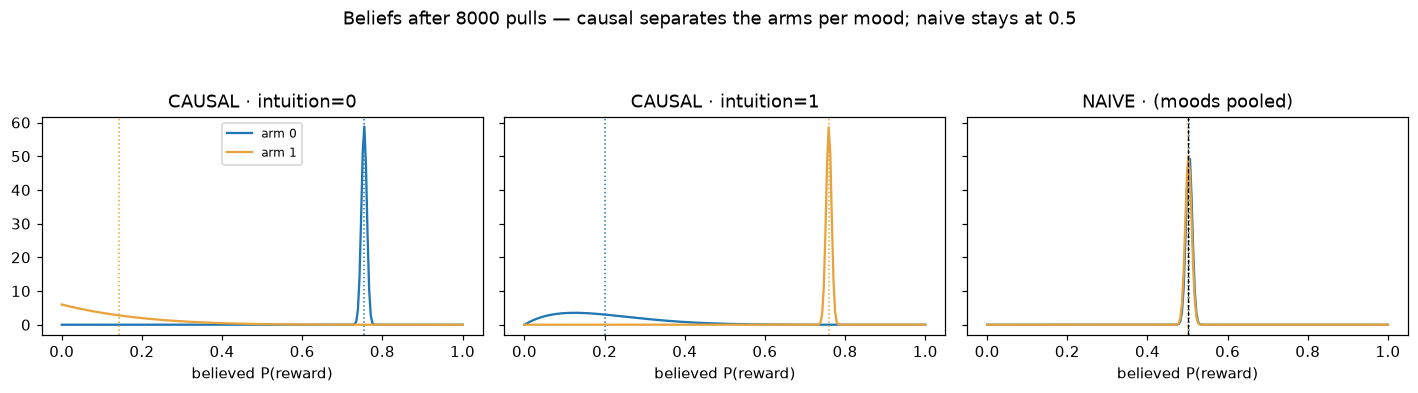

In [3]:
def draw_beliefs(step):
    """Beta densities at a training step: causal split by intuition, naive pooled."""
    xs = np.linspace(0, 1, 250)
    ca, cb = causal_snaps[step]
    na, nb = naive_snaps[step]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)

    for ctx, ax in zip((0, 1), axes[:2]):
        for arm, color in zip((0, 1), (BLUE, GOLD)):
            a, b = ca[ctx, arm], cb[ctx, arm]
            ax.plot(xs, beta_dist.pdf(xs, a, b), color=color, label=f"arm {arm}")
            ax.axvline(a / (a + b), color=color, ls=":", lw=1)
        ax.set_title(f"CAUSAL · intuition={ctx}")
        ax.set_xlabel("believed P(reward)")
    axes[0].legend(loc="upper center", fontsize=8)

    ax = axes[2]
    for arm, color in zip((0, 1), (BLUE, GOLD)):
        a, b = na[arm], nb[arm]
        ax.plot(xs, beta_dist.pdf(xs, a, b), color=color, label=f"arm {arm}")
        ax.axvline(a / (a + b), color=color, ls=":", lw=1)
    ax.axvline(0.5, color="k", ls="--", lw=0.8)
    ax.set_title("NAIVE · (moods pooled)")
    ax.set_xlabel("believed P(reward)")

    fig.suptitle(f"Beliefs after {step} pulls — causal separates the arms per mood; naive stays at 0.5",
                 fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    plt.show()


# ▦ static: the endpoint (also validates the drawing logic headlessly)
draw_beliefs(8000)

In [4]:
# ▶ live: drag through training and watch the causal beliefs pull apart
widgets.interact(draw_beliefs,
                 step=widgets.SelectionSlider(options=SNAP_STEPS, value=10,
                                              description="pulls", continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='pulls', index=3, options=(0, 2, 5,…

In [5]:
# ▶ live: pull ONE more time and watch both agents decide on the same fresh mood
_live_env = MABUCEnv(seed=99)
_live_rng = np.random.default_rng(7)
_tally = {"causal": 0, "naive": 0, "n": 0}
_out = widgets.Output()


def _pull_once(_btn=None):
    obs, _ = _live_env.reset()
    cctx, cth, ca, cr = transparent_pull(causal, obs, _live_env, _live_rng)
    obs2 = {"intuition": cctx}
    nctx, nth, na_, nr = transparent_pull(naive, obs2, _live_env, _live_rng)
    _tally["causal"] += cr; _tally["naive"] += nr; _tally["n"] += 1
    with _out:
        print(f"mood→intuition={cctx} | "
              f"CAUSAL sampled {cth.round(2)} → arm {ca} (r={cr:.0f})   "
              f"NAIVE sampled {nth.round(2)} → arm {na_} (r={nr:.0f})   "
              f"|| running reward  causal={_tally['causal']/_tally['n']:.2f} "
              f"naive={_tally['naive']/_tally['n']:.2f}")


_btn = widgets.Button(description="🎲 pull once", button_style="primary")
_btn.on_click(_pull_once)
display(_btn, _out)

Button(button_style='primary', description='🎲 pull once', style=ButtonStyle())

Output()

## Demo 2 — POMIS: touch the 27 levers, keep the 2 that matter

Now the choice is *which variables to set*. The chain is $X_1\to X_2\to X_3\to Y$ with a hidden
back-door $X_1\leftrightarrow Y$. Each of $X_1,X_2,X_3$ can be left alone or forced to 0/1 →
**27 candidate arms**. One line of theory: setting an upstream variable destroys the very
$X_3\to Y$ effect you want, so POMIS proves only two arms can be optimal,
$\{\varnothing,\{X_3\}\}$.

Below you can **poke any of the 27 arms** and read its true value — discover for yourself that
plain *observing* ($\varnothing$) is the winner.

In [6]:
from causalrl import pomis
from causalrl.envs.suite.scbandit import make_confounded_chain_env

chain_env = make_confounded_chain_env(seed=1)
pomis_sets = pomis(chain_env.graph, "Y")
pomis_keys = {frozenset(s) for s in pomis_sets}


def arm_label(arm):
    return "∅  (just observe)" if not arm else "do(" + ", ".join(f"{k}={v}" for k, v in arm.items()) + ")"


def in_pomis(arm):
    return frozenset(arm.keys()) in pomis_keys


# ▦ static: the whole action space, value and POMIS membership (validates the helpers)
print(f"{len(chain_env.arms)} candidate arms; POMIS keeps {len(pomis_sets)}: {pomis_sets}\n")
ranked = sorted(range(len(chain_env.arms)), key=lambda i: -chain_env.arm_values[i])
print("  value  POMIS  arm")
for i in ranked[:6]:
    arm = chain_env.arms[i]
    print(f"  {chain_env.arm_values[i]:.3f}   {'✓ ' if in_pomis(arm) else '· '}    {arm_label(arm)}")
print("  ...")

27 candidate arms; POMIS keeps 2: [frozenset(), frozenset({'X3'})]

  value  POMIS  arm
  1.000   ✓     ∅  (just observe)
  0.530   ·     do(X2=1, X3=0)
  0.520   ·     do(X1=0, X2=1, X3=1)
  0.518   ✓     do(X3=1)
  0.517   ·     do(X1=0)
  0.514   ·     do(X2=1, X3=1)
  ...


In [7]:
# ▶ live: pick any lever and read its value + whether POMIS bothered to keep it
def show_arm(idx):
    arm = chain_env.arms[idx]
    val = chain_env.arm_values[idx]
    keep = in_pomis(arm)
    bar = "█" * int(round(val * 30))
    print(f"{arm_label(arm):>22}   value = {val:.3f}  {bar}")
    print(f"{'':>22}   POMIS keeps this lever? {'YES ✓' if keep else 'no — provably not optimal'}")
    if not arm:
        print("\n   ↑ doing nothing but *observing* is the best arm here (the MABUC effect on a chain).")


widgets.interact(show_arm,
                 idx=widgets.Dropdown(options=[(arm_label(a), i) for i, a in enumerate(chain_env.arms)],
                                      value=0, description="lever"));

interactive(children=(Dropdown(description='lever', options=(('∅  (just observe)', 0), ('do(X1=0)', 1), ('do(X…

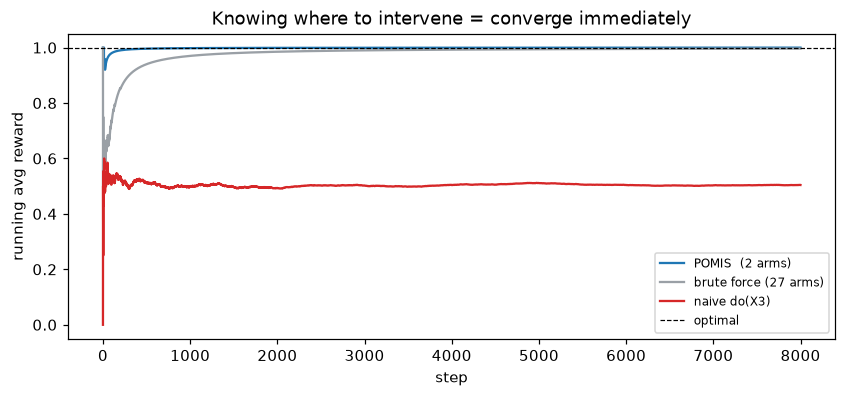

In [8]:
# ▶ live + ▦ scoreboard: POMIS agent searches 2 arms, brute force flails over 27
from causalrl.agents.scbandit import (
    BruteForceInterventionTS, FixedSetThompsonSampling, POMISThompsonSampling,
)


def tail_reward(agent, steps=8000, seed=1):
    obs, _ = chain_env.reset(seed=seed)
    rewards = []
    for _ in range(steps):
        a = agent.act(obs)
        nobs, r, _, _, _ = chain_env.step(a)
        agent.update(obs, a, r)
        rewards.append(r)
        obs = nobs
    return np.asarray(rewards, float)


pomis_r = tail_reward(POMISThompsonSampling(chain_env.graph, chain_env.reward, chain_env.arms,
                                            seed=0, manipulable=chain_env.manipulable))
brute_r = tail_reward(BruteForceInterventionTS(chain_env.arms, seed=0), seed=2)
naive_r = tail_reward(FixedSetThompsonSampling(chain_env.arms, {"X3"}, seed=0), seed=3)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(np.cumsum(pomis_r) / (np.arange(8000) + 1), color=BLUE, label="POMIS  (2 arms)")
ax.plot(np.cumsum(brute_r) / (np.arange(8000) + 1), color=GREY, label="brute force (27 arms)")
ax.plot(np.cumsum(naive_r) / (np.arange(8000) + 1), color=RED, label="naive do(X3)")
ax.axhline(chain_env.optimal_value, ls="--", c="k", lw=0.8, label="optimal")
ax.set_xlabel("step"); ax.set_ylabel("running avg reward")
ax.set_title("Knowing where to intervene = converge immediately"); ax.legend(fontsize=8)
plt.show()

## Demo 3 — Counterfactual policy: play one round at a time

A 3-arm bandit where the lucky arm *is* the hidden state $U$, and your intent $I=U$. One line of
theory: every fixed intervention averages to chance,
$\mathbb{E}[Y\mid do(X{=}a)]\approx0.37$ for all $a$, but the **counterfactual** value
$\mathbb{E}[Y_{do(a)}\mid I{=}i]$ is sharp — it tells you to play the arm matching your intent.

The agent precomputes that table from the model. Below you can **play single rounds** and watch
the counterfactual policy follow its intent and win while the naive agent guesses.

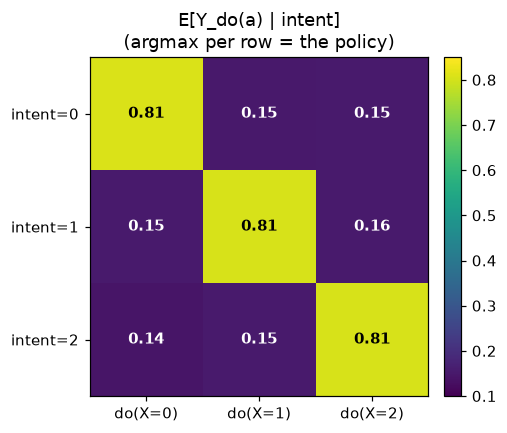

marginal E[Y|do(X=a)] over intents: [0.368 0.37  0.372]  → every fixed arm ~0.37


In [9]:
from causalrl import CounterfactualOptimalPolicy
from causalrl.agents.bandits import NaiveThompsonSampling
from causalrl.envs.suite.counterfactual_bandit import (
    build_counterfactual_scm, make_counterfactual_bandit_env,
)

cf_agent = CounterfactualOptimalPolicy(
    build_counterfactual_scm(), outcome="Y", action_node="X", intent_node="I",
    arms=[0, 1, 2], intents=[0, 1, 2], seed=0,
)
table = cf_agent.decision_table
M = np.array([[table[i][a] for a in (0, 1, 2)] for i in (0, 1, 2)])

# ▦ static: the decision table the agent acts on (diagonal = "play your intuition")
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(M, cmap="viridis", vmin=0.1, vmax=0.85)
ax.set_xticks([0, 1, 2], ["do(X=0)", "do(X=1)", "do(X=2)"])
ax.set_yticks([0, 1, 2], ["intent=0", "intent=1", "intent=2"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                color="white" if M[i, j] < 0.5 else "black", fontweight="bold")
ax.set_title("E[Y_do(a) | intent]\n(argmax per row = the policy)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()
print("marginal E[Y|do(X=a)] over intents:", M.mean(axis=0).round(3), " → every fixed arm ~0.37")

In [10]:
# ▶ live: play one round; counterfactual policy follows intent, naive guesses
_cf_env = make_counterfactual_bandit_env(seed=3)
_cf_naive = NaiveThompsonSampling(n_arms=3, seed=0)
_cf_tally = {"cf": 0, "naive": 0, "n": 0}
_cf_out = widgets.Output()


def _play_round(_btn=None):
    obs, _ = _cf_env.reset()
    intent = obs["intuition"]
    a_cf = cf_agent.act(obs)
    _, r_cf, _, _, _ = _cf_env.step(a_cf)
    a_nv = _cf_naive.act(obs)
    obs2, _ = _cf_env.reset(); obs2 = {"intuition": intent}; _cf_env._u = intent
    _, r_nv, _, _, _ = _cf_env.step(a_nv)
    _cf_naive.update(obs, a_nv, r_nv)
    _cf_tally["cf"] += r_cf; _cf_tally["naive"] += r_nv; _cf_tally["n"] += 1
    with _cf_out:
        print(f"intent={intent} | COUNTERFACTUAL → arm {a_cf} (table says {M[intent].round(2)}) "
              f"r={r_cf:.0f}   NAIVE → arm {a_nv} r={r_nv:.0f}   "
              f"|| avg  cf={_cf_tally['cf']/_cf_tally['n']:.2f} naive={_cf_tally['naive']/_cf_tally['n']:.2f}")


_cf_btn = widgets.Button(description="🎲 play a round", button_style="primary")
_cf_btn.on_click(_play_round)
display(_cf_btn, _cf_out)

Button(button_style='primary', description='🎲 play a round', style=ButtonStyle())

Output()

## What you just watched

In all three games the **intervention** signal alone was useless — every arm looked identical
under $do$. The causal agent won because it could *see and use* something extra, and you watched
exactly where:

1. **MABUC** — beliefs **split by context**: the causal agent kept a separate posterior per mood, so its arms pulled apart while the naive agent's stayed glued at 0.5.
2. **POMIS** — the graph **pruned 27 levers to 2** before any data; you poked the rest and confirmed they're worse.
3. **Counterfactual** — the agent **read its intent off a precomputed table** and played the matching arm, round after round.

### Next stops in `causalrl`
- `examples/offline_to_online.ipynb` — learning from confounded logs (Manski bounds).
- `identify_effect`, `certify_decision`, `manski_bounds` — the conservative identification layer.
- The **Tour by Task** in the docs covers transportability, discovery, imitation, curriculum, shaping and games.

*Static figures for slides:* `uv run python examples/presentation/_build_figures.py`.